In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x}')

In [3]:
merge = articles = pd.read_csv(r"merge_data.csv", encoding="utf-8")

In [4]:
#고객 세그먼트(연령대) 파생
# 연령 구간(bins) 설정
bins = [10, 20, 30, 40, 50, 100]  

# 라벨 설정
labels = ['10대', '20대', '30대', '40대', '50대 이상']
merge['age_group'] = pd.cut(merge['age'], bins=bins, labels=labels, right=True)

In [5]:
merge['age_group']

0         50대 이상
1            20대
2            30대
3            10대
4            30대
           ...  
805038       40대
805039       20대
805040       30대
805041       40대
805042       40대
Name: age_group, Length: 805043, dtype: category
Categories (5, object): ['10대' < '20대' < '30대' < '40대' < '50대 이상']

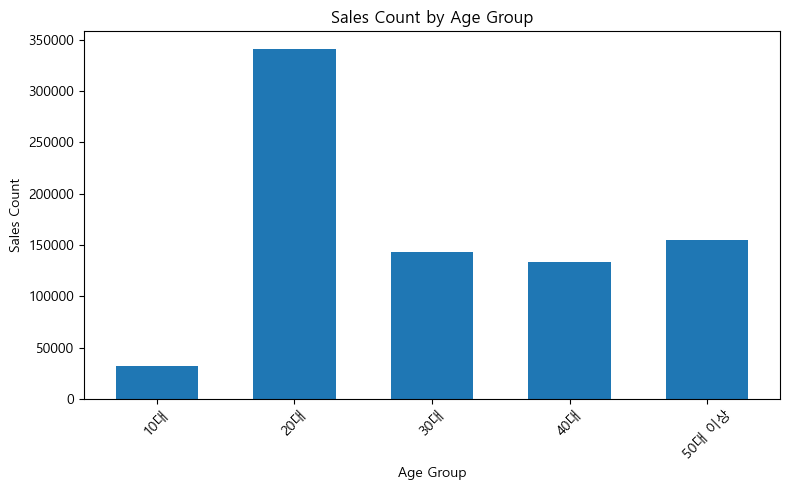

In [6]:
import warnings
warnings.filterwarnings("ignore")

#고객 세그먼트별 거래 건수
count_by_group = merge.groupby('age_group')['customer_id'].count()

count_sales =  pd.DataFrame({
    'age_group': count_by_group.index,
    'sales_count': count_by_group.values,
})

#시각화
plt.figure(figsize=(8,5))
plt.bar(count_sales['age_group'], count_sales['sales_count'],width = 0.6)
plt.title('Sales Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sales Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

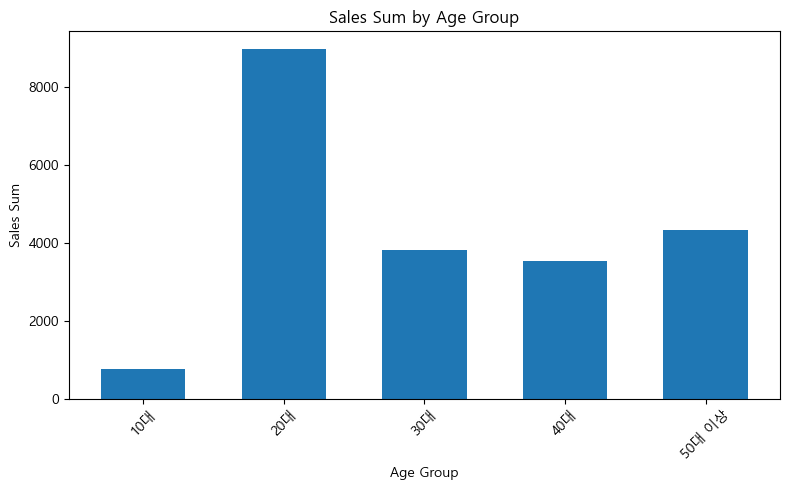

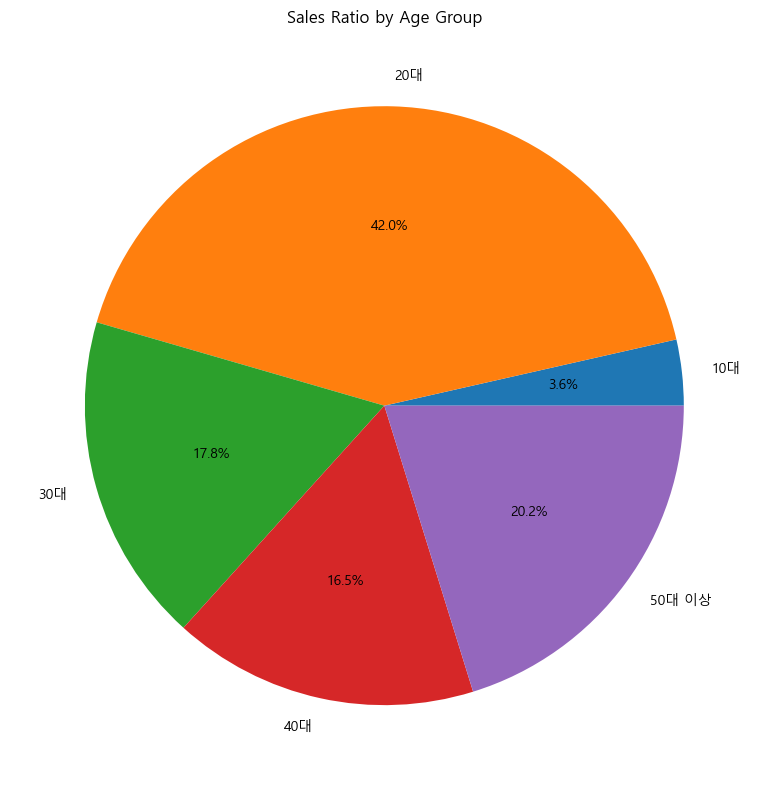

In [7]:
#각 고객 세그먼트별 매출 합계, 비율

sales_by_group = merge.groupby('age_group')['price'].sum()
sales_by_ratio = ((sales_by_group / sales_by_group.sum())*100).round(2)

merge_sales = pd.DataFrame({
    'age_group': sales_by_group.index,
    'sales_sum': sales_by_group.values,
    'sales_ratio': sales_by_ratio.values
})


#시각화
plt.figure(figsize=(8,5))
plt.bar(merge_sales['age_group'], merge_sales['sales_sum'],width = 0.6)
plt.title('Sales Sum by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sales Sum')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))
plt.pie(merge_sales['sales_ratio'], labels=merge_sales['age_group'], autopct='%1.1f%%')
plt.title('Sales Ratio by Age Group')
plt.tight_layout()
plt.show()

In [8]:
#고객 세그먼트 별 평균 매출액 
mean_sales = merge.groupby("age_group")["price"].mean().reset_index()
mean_sales

,age_group,price
0,10대,0.02378269322374515
1,20대,0.02634367752674072
2,30대,0.02655048405565118
3,40대,0.026389864932748867
4,50대 이상,0.027977372501441687


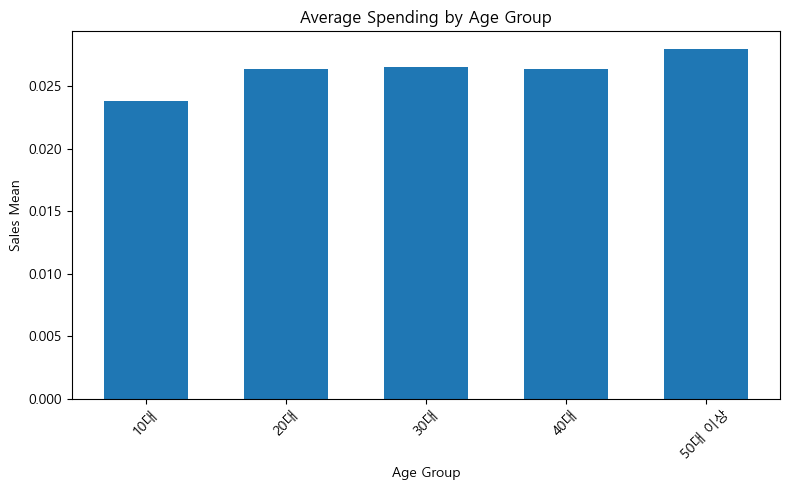

In [9]:
plt.figure(figsize=(8,5))
plt.bar(mean_sales['age_group'], mean_sales['price'],width = 0.6)
plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sales Mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

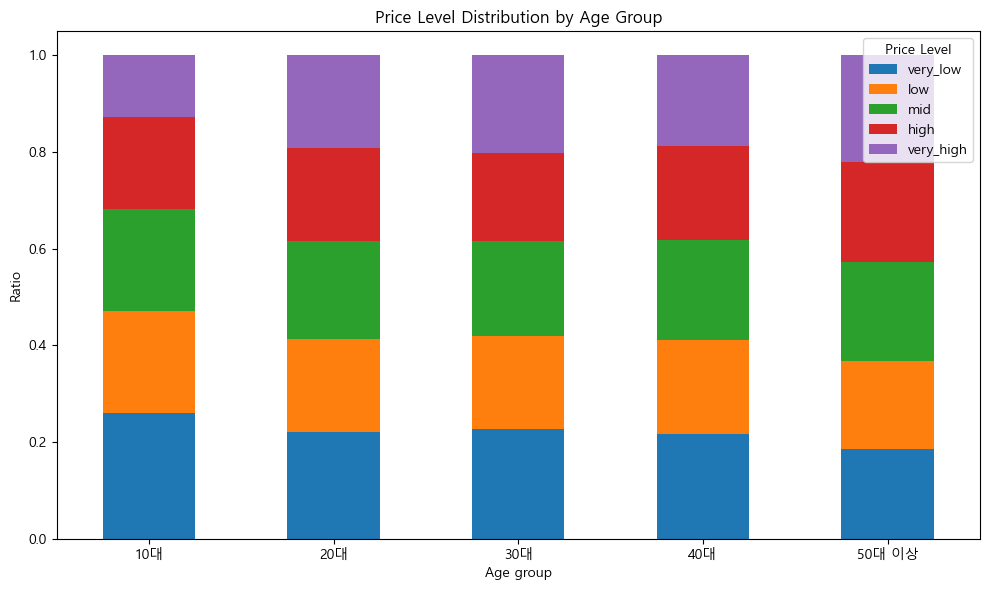

In [10]:
#각 고객 세그먼트가 선호하는 가격대
merge["price_level"] = pd.qcut(
    merge["price"], 
    5, 
    labels=["very_low", "low", "mid", "high", "very_high"])

age_price_dist = (
    merge.groupby("age_group")["price_level"]
    .value_counts(normalize=True)
    .unstack())

#시각화
plt.figure(figsize=(10, 6))
age_price_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Price Level Distribution by Age Group")
plt.xlabel("Age group")
plt.ylabel("Ratio")
plt.legend(title="Price Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

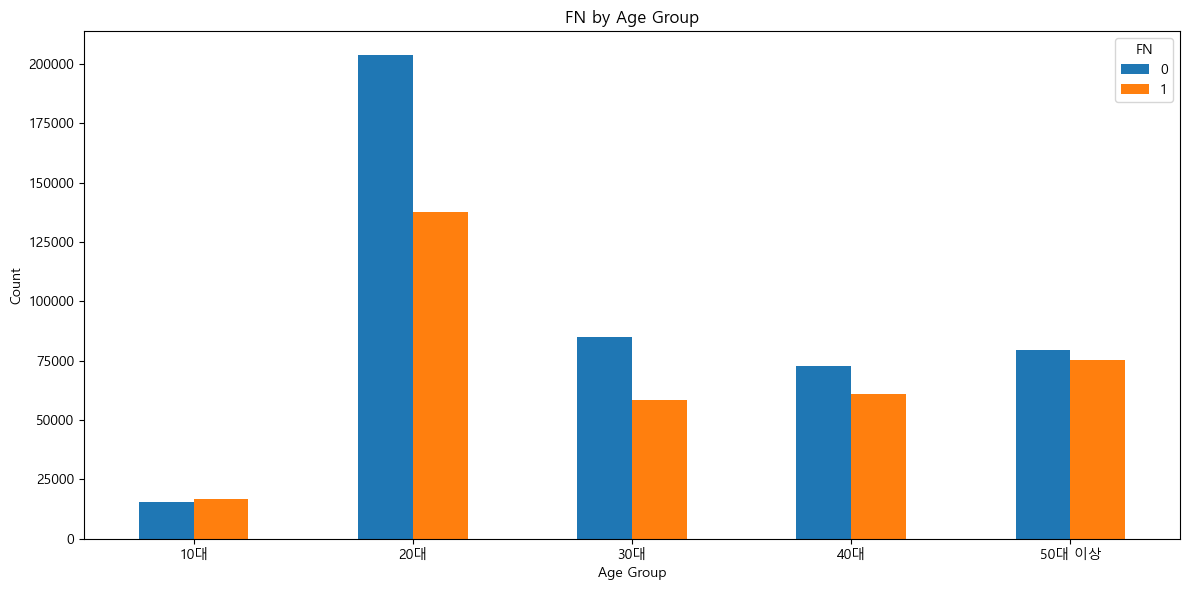

In [11]:
#연령대별 패션뉴스 구독자 수
FN_count_pivot = merge.pivot_table(
    index='FN',
    columns= 'age_group',
    values='customer_id',
    aggfunc='count',
    fill_value=0,
)


FN_count_pivot.T.plot(kind="bar", figsize=(12, 6))

plt.title("FN by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="FN")
plt.tight_layout()
plt.show()

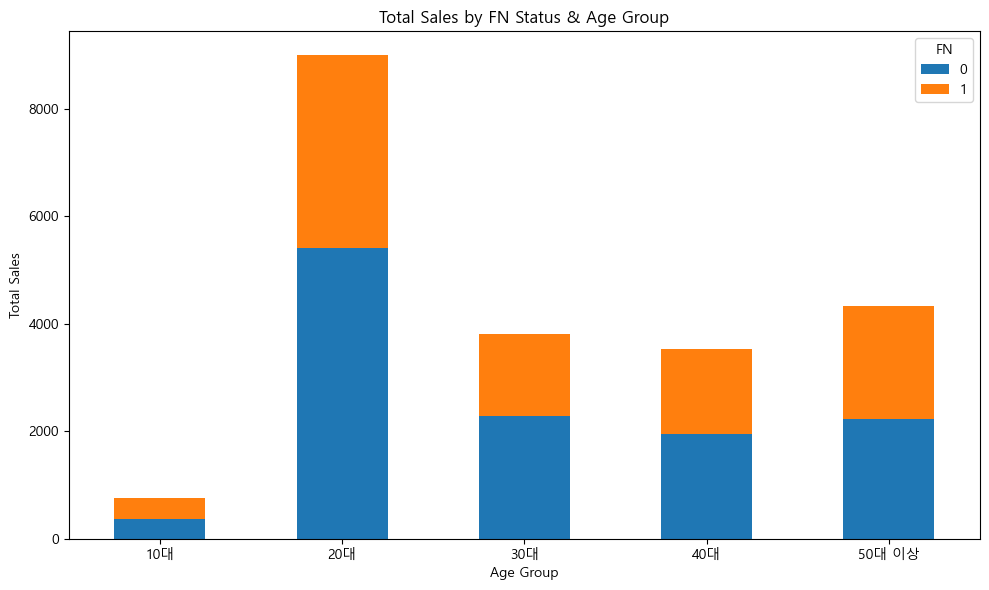

In [12]:
#연령대 X 패션뉴스구독여부 - 매출합계
FN_sales_pivot = merge.pivot_table(
    index='FN',
    columns='age_group',
    values='price',
    aggfunc='sum',
    fill_value=0,
)

FN_sales_pivot.T.plot(kind="bar", stacked = True, figsize=(10, 6))
plt.title("Total Sales by FN Status & Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.legend(title="FN")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

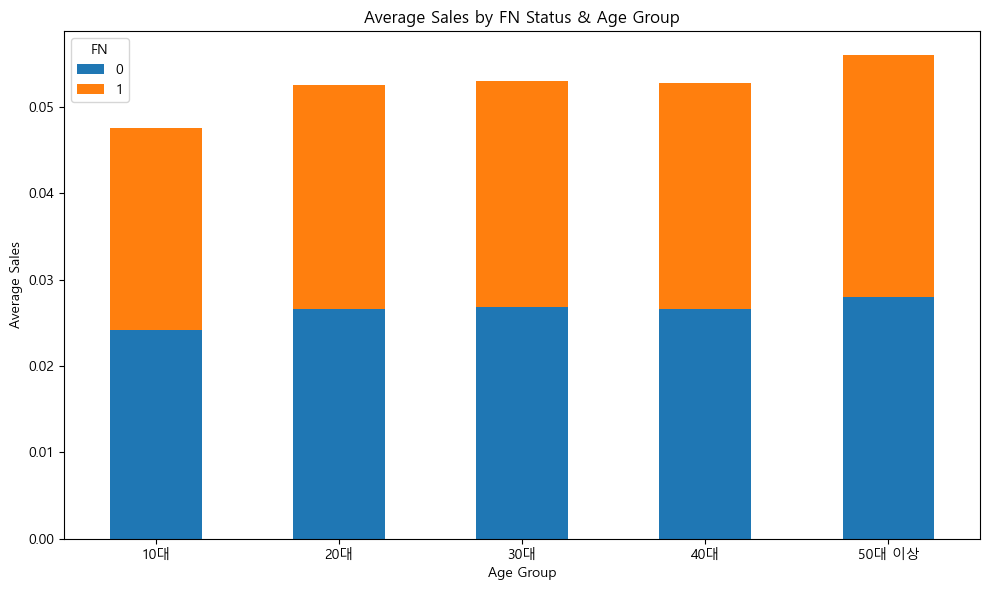

In [13]:
#연령대 X 패션뉴스구독여부 - 매출평균
FN_mean_pivot = merge.pivot_table(
    index='age_group',
    columns='FN',
    values='price',
    aggfunc='mean',
    fill_value=0,
)

FN_mean_pivot.plot(kind="bar", stacked = True, figsize=(10, 6))
plt.title("Average Sales by FN Status & Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Sales")
plt.legend(title="FN")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
#연령대별 Active 가능한 사람 수 
Active_count_pivot = merge.pivot_table(
    index='age_group',
    columns='Active',
    values='customer_id',
    aggfunc='count',
    fill_value=0,
)

Active_count_pivot

Active,0,1
age_group,,
10대,15856,16100
20대,205812,135297
30대,85865,57636
40대,73566,60231
50대 이상,79973,74707


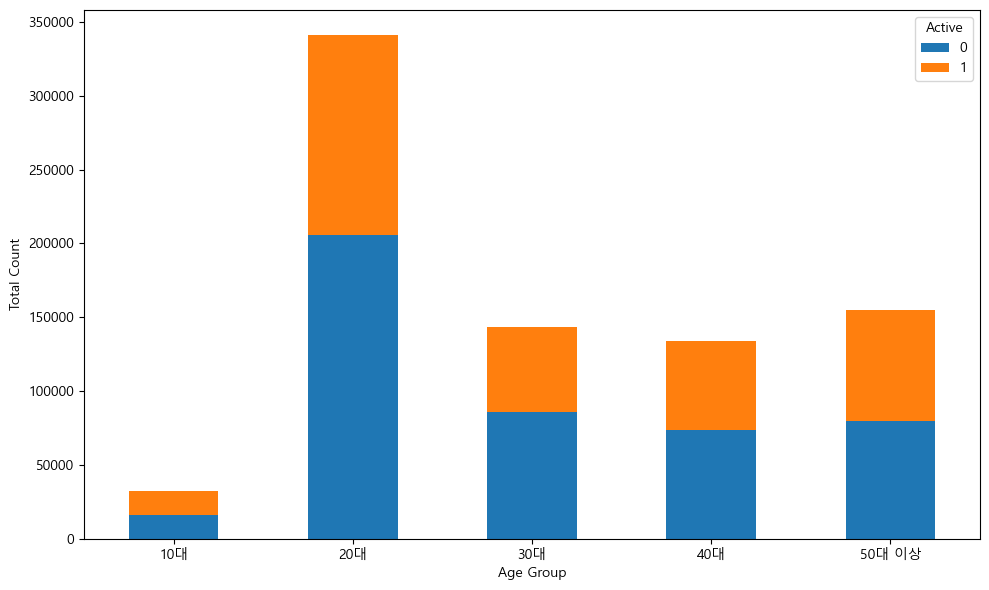

In [15]:
#시각화
Active_count_pivot.plot(kind="bar", stacked = True, figsize=(10, 6))
plt.title("")
plt.xlabel("Age Group")
plt.ylabel("Total Count")
plt.legend(title="Active")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

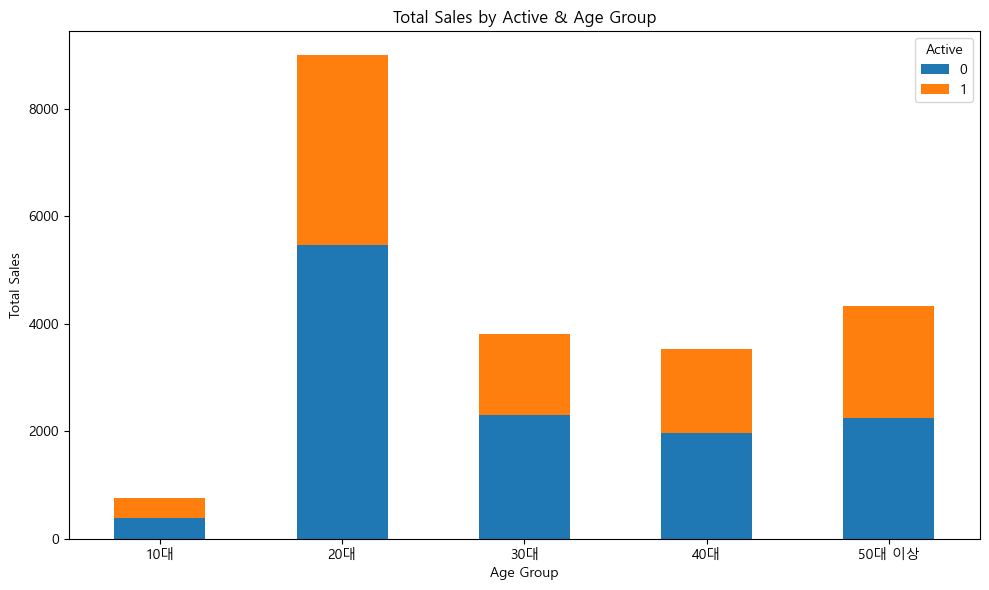

In [16]:
#연령대 X Active여부 - 매출합계
Active_sales_pivot = merge.pivot_table(
    index='age_group',
    columns='Active',
    values='price',
    aggfunc='sum',
    fill_value=0,
)

Active_sales_pivot.plot(kind="bar", stacked = True, figsize=(10, 6))
plt.title("Total Sales by Active & Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.legend(title="Active")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

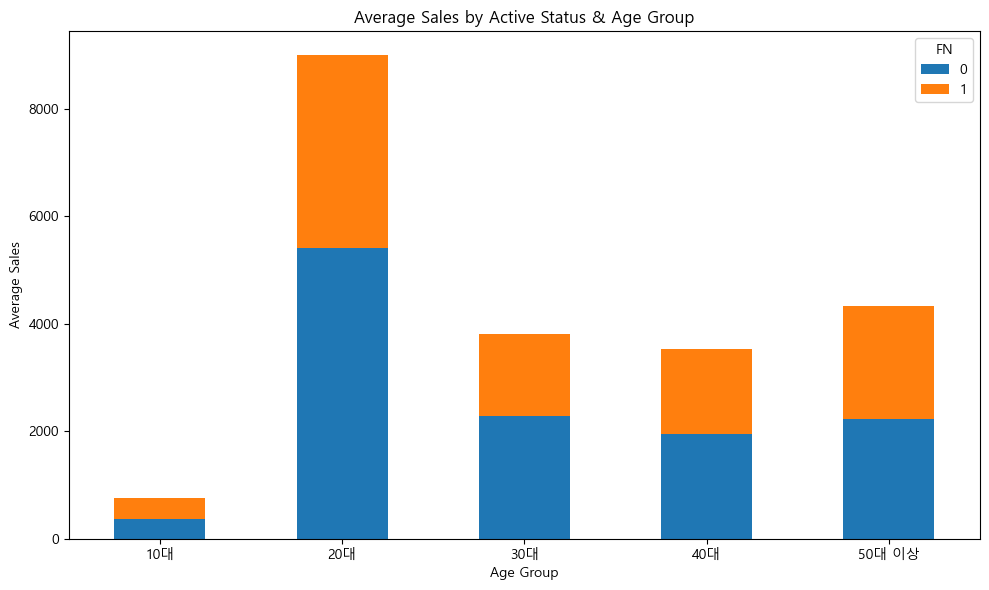

In [17]:
#연령대 X Active여부 - 매출평균
Active_sales_pivot = merge.pivot_table(
    index='age_group',
    columns='Active',
    values='price',
    aggfunc='mean',
    fill_value=0,
)

FN_sales_pivot.T.plot(kind="bar", stacked = True, figsize=(10, 6))
plt.title("Average Sales by Active Status & Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Sales")
plt.legend(title="FN")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

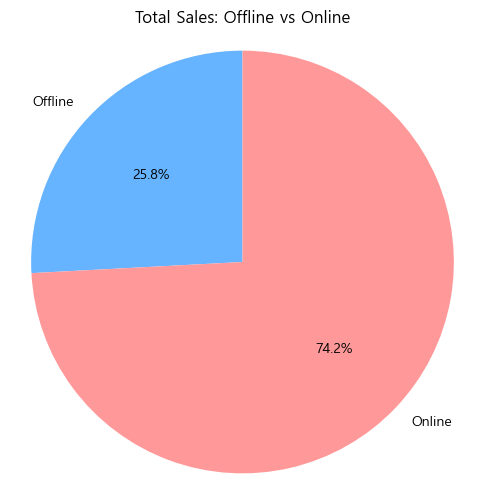

In [51]:
# 온오프라인 매출 비교: 온라인 채널(sales_channel_id=2)의 기록이 상대적으로 많을 수 있습니다.
# 표본 편향으로 인한 채널 비중 왜곡 가능성이 있습니다. 


filtered_offline = merge[merge['sales_channel_id'] == 1]
sales_offline = filtered_offline['price'].sum()

filtered_online = merge[merge['sales_channel_id'] == 2]
sales_online = filtered_online['price'].sum()

offline_online_sales = pd.DataFrame({
    'sales_online': [sales_online],
    'sales_offline': [sales_offline]
})

offline_online_sales


filtered_off = merge[merge['sales_channel_id'] == 1]
count_offline = filtered_off['customer_id'].count()

filtered_on = merge[merge['sales_channel_id'] == 2]
count_online = filtered_on['customer_id'].count()

offline_online_count = pd.DataFrame({
    'count_online': [count_online],
    'count_offline': [count_offline]
})

offline_online_count


#시각화
import matplotlib.pyplot as plt

sales_values = [sales_offline, sales_online]
labels = ['Offline', 'Online']
colors = ['#66b3ff', '#ff9999']  

plt.figure(figsize=(6,6))
plt.pie(sales_values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Total Sales: Offline vs Online')
plt.axis('equal')  # 원형으로 만들기
plt.show()


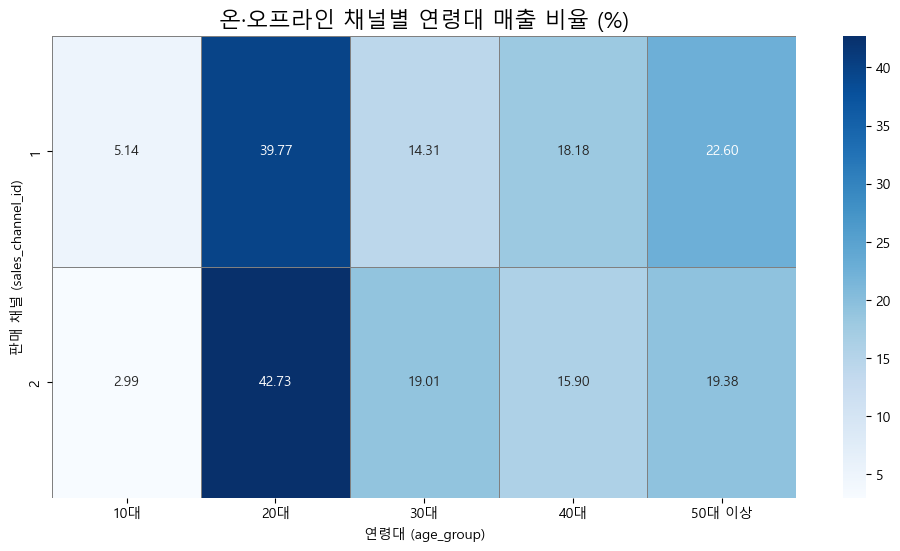

In [27]:
# 온오프라인 고객 세그먼트별(연령대) 매출 비교: 
# 온라인 채널(sales_channel_id=2)의 기록이 상대적으로 많을 수 있습니다. 
# 표본 편향으로 인한 채널 비중 왜곡 가능성이 있습니다.

sales_by_group_channel = merge.groupby(['age_group', 'sales_channel_id'])['price'].sum()


total_sales = merge.groupby(['sales_channel_id'])['price'].sum()


sales_by_ratio = ((sales_by_group_channel / total_sales) * 100).round(2)


merge_sales_channel = pd.DataFrame({
    'sales_sum': sales_by_group_channel,
    'sales_ratio': sales_by_ratio
}).reset_index()


pivot_sales_ratio = merge_sales_channel.pivot_table(
    index='sales_channel_id',
    columns='age_group',
    values='sales_ratio',
    fill_value=0  # NaN은 0으로 채움
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_sales_ratio,
    annot=True,        
    fmt=".2f",         
    cmap='Blues',      
    linewidths=0.5,    
    linecolor='gray'
)

plt.title("온·오프라인 채널별 연령대 매출 비율 (%)", fontsize=16)
plt.xlabel("연령대 (age_group)")
plt.ylabel("판매 채널 (sales_channel_id)")

plt.show()

<Figure size 1200x600 with 0 Axes>

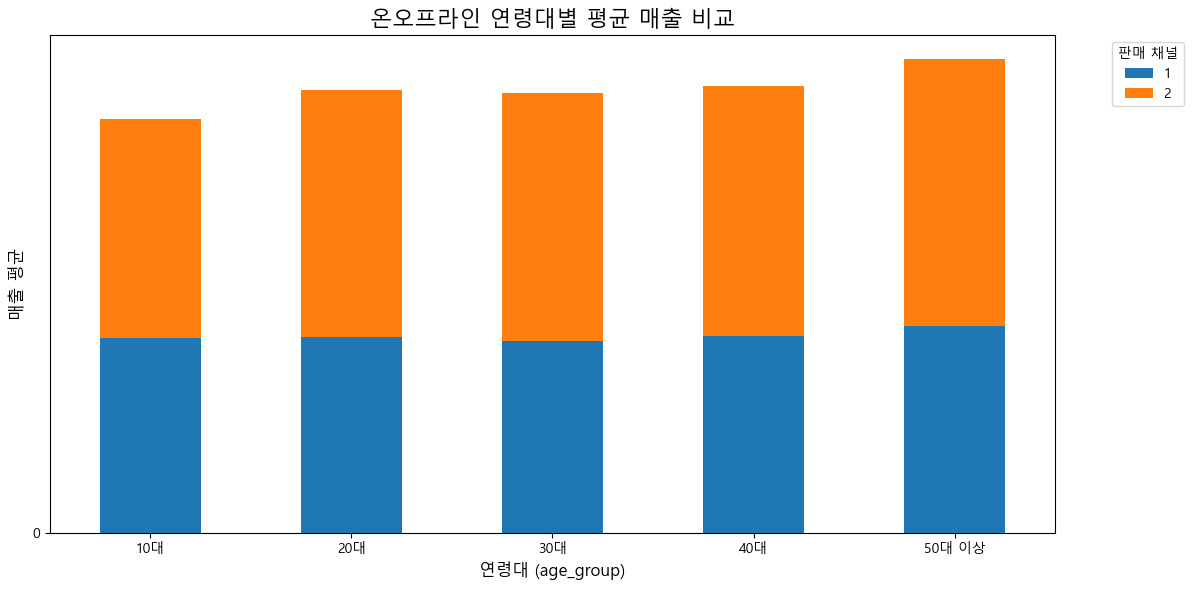

In [29]:
#온오프라인 고객 세그먼트별(연령대) 매출 평균 비교
sales_mean_by_group_channel = merge.groupby(['age_group', 'sales_channel_id'])['price'].mean()
sales_mean_by_group_channel



mean_sales_channel = pd.DataFrame({
    'sales_mean': sales_mean_by_group_channel,
}).reset_index()

pivot_sales_mean = mean_sales_channel.pivot_table(
    index='sales_channel_id',
    columns='age_group',
    values='sales_mean',
    fill_value=0 
)

df_plot = pivot_sales_mean.T

plt.figure(figsize=(12, 6))
ax = df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('온오프라인 연령대별 평균 매출 비교', fontsize=16)
plt.xlabel('연령대 (age_group)', fontsize=12)
plt.ylabel('매출 평균', fontsize=12)
plt.yticks(range(0,1))
plt.xticks(rotation=0)
plt.legend(title='판매 채널', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [36]:
#고객 세그먼트별 선호하는 제품군 
products_prefer=merge.groupby(['age_group', 'product_group_name'])['price'].sum().reset_index()

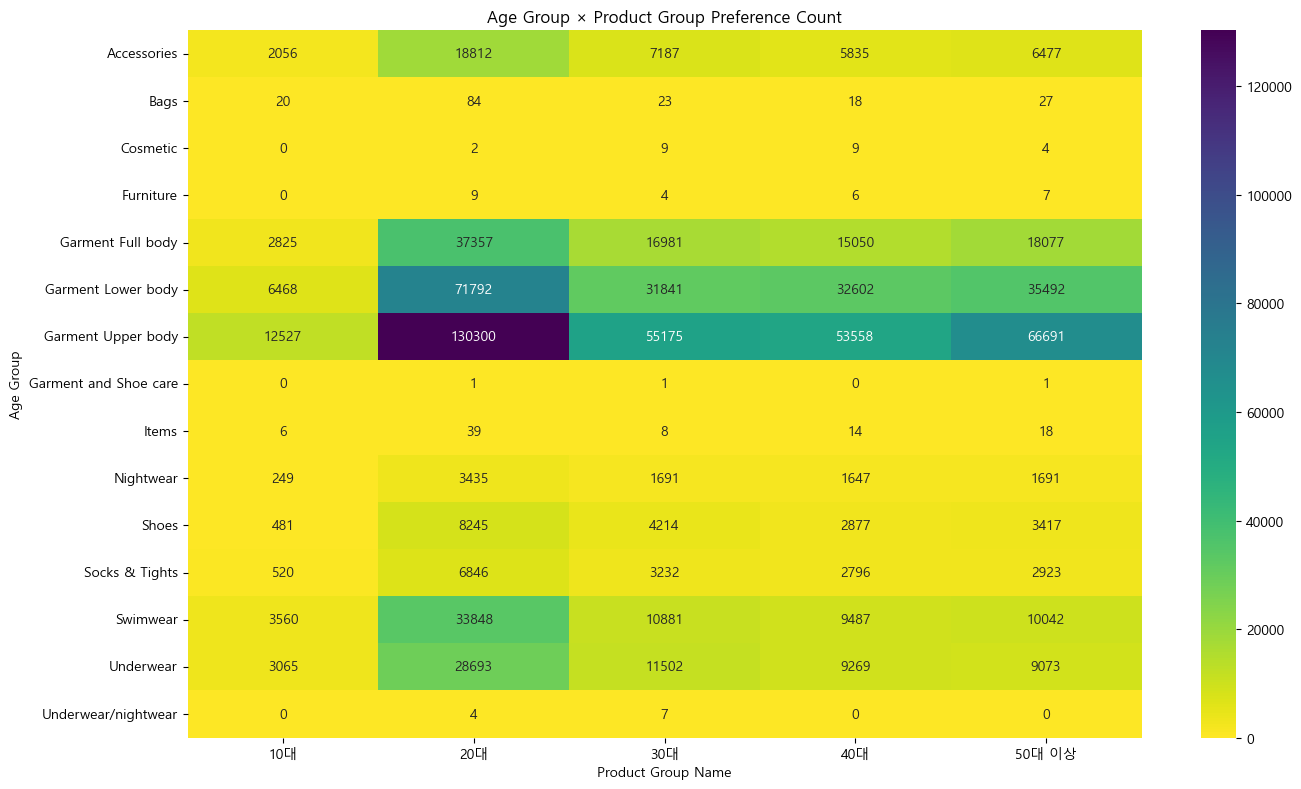

In [37]:
#제품군  x 연령대 구매건수 
products_prefer_count=merge.groupby(['age_group', 'product_group_name'])['customer_id'].count().reset_index()
pivot_products_prefer = products_prefer_count.pivot_table(
    index='product_group_name',
    columns='age_group',
    values='customer_id',
    fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_products_prefer, fmt='.0f', annot=True, cmap='viridis_r')
plt.title('Age Group × Product Group Preference Count')
plt.xlabel('Product Group Name')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()


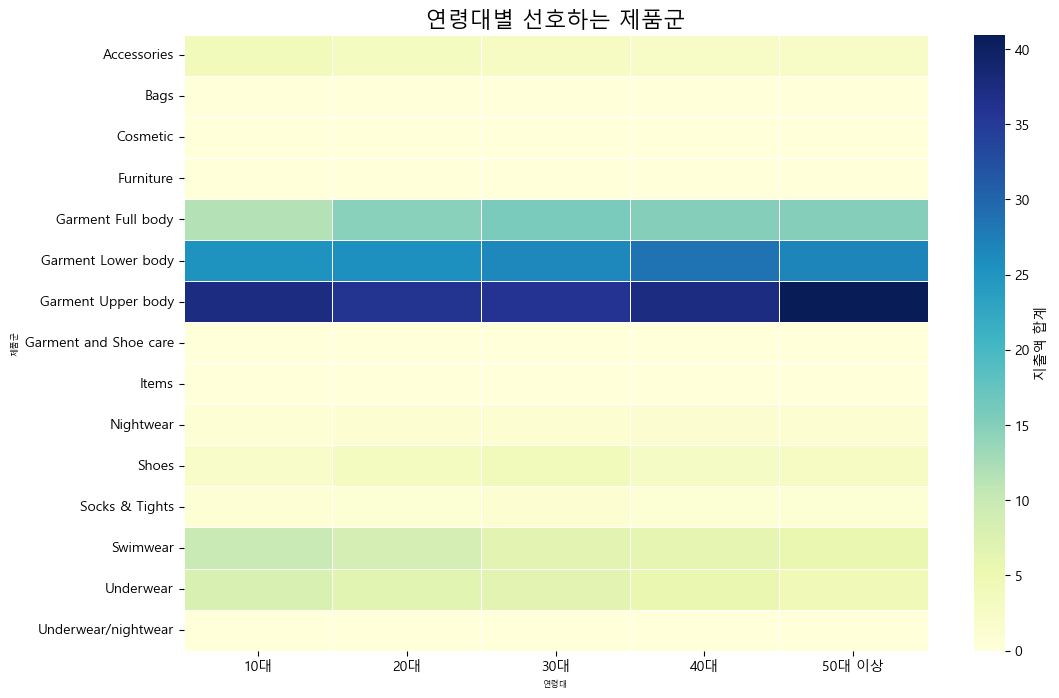

In [33]:
# 제품군 × 연령대 매출 합계 pivot
pivot_result = products_prefer.pivot_table(
    index='product_group_name',
    columns='age_group',
    values='price',
    aggfunc='sum'
).fillna(0)

# 연령대별 전체 매출액 (각 column의 총합)
age_total_sales = pivot_result.sum(axis=0)

# 제품군별 매출을 연령대별 총매출로 나눈 비율 계산
pivot_ratio = pivot_result.div(age_total_sales, axis=1) * 100

# 보기 좋게 반올림
pivot_ratio_final = pivot_ratio.round(2)

#시각화
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

plt.figure(figsize=(12, 8)) # 그래프 크기 설정
sns.heatmap(
    pivot_ratio_final,
    annot=False,        # 셀에 실제 값(지출액) 표시
    fmt=".2f",         # 표시되는 값의 형식 (소수점 두 자리)
    cmap="YlGnBu",     # 색상 맵 설정 (지출액이 높을수록 진한 색)
    linewidths=.5,     # 셀 경계선 설정
    cbar_kws={'label': '지출액 합계'} # 컬러 바 라벨 설정
)
plt.title('연령대별 선호하는 제품군', fontsize=16)
plt.xlabel('연령대', fontsize=6)
plt.ylabel('제품군', fontsize=6)
plt.show()

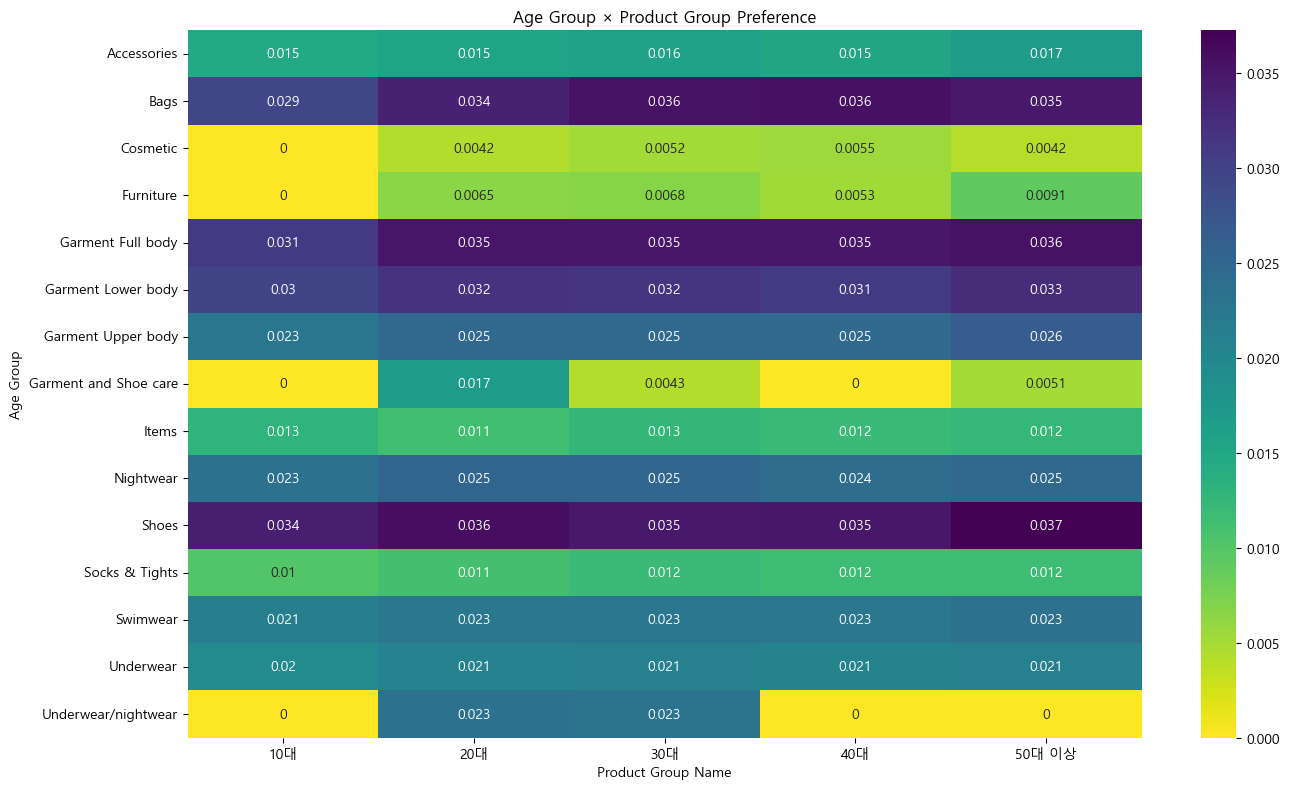

In [35]:
# 제품군 × 연령대 매출 평균 pivot
products_prefer_mean=merge.groupby(['age_group', 'product_group_name'])['price'].mean().reset_index()
pivot_products_mean = products_prefer_mean.pivot_table(
    index='product_group_name',
    columns='age_group',
    values='price',
    fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_products_mean, annot=True, cmap='viridis_r')
plt.title('Age Group × Product Group Preference')
plt.xlabel('Product Group Name')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()


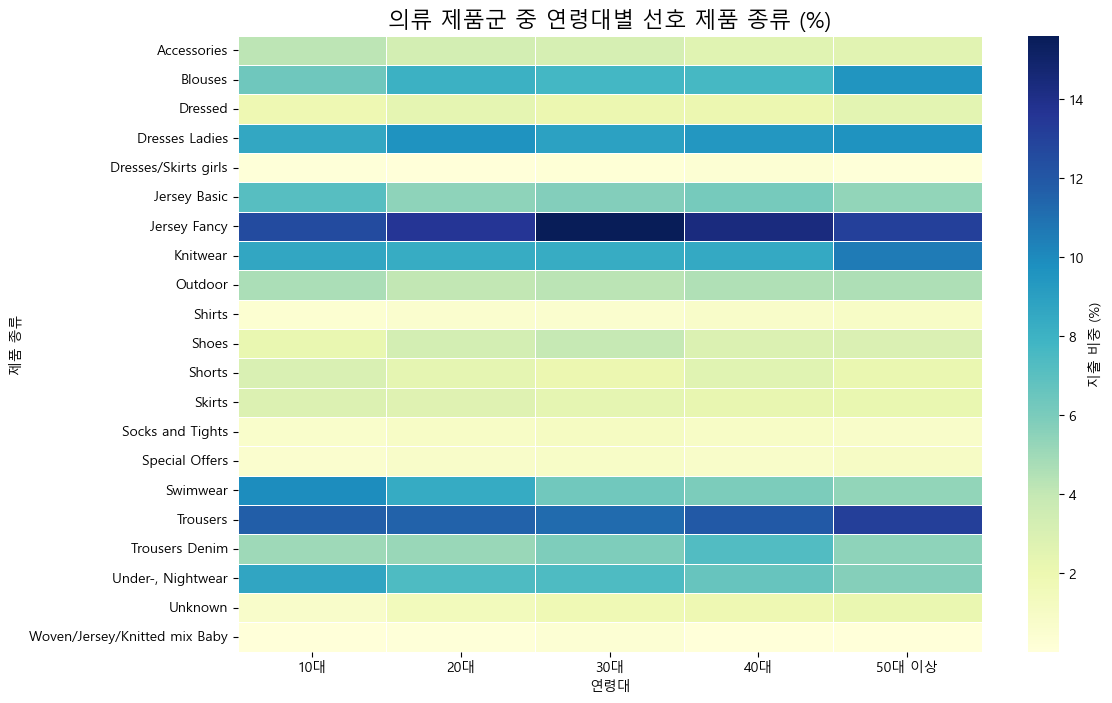

In [39]:
# '의류' 제품군에서 각 고객 세그먼트 별 선호하는 제품 종류


products_prefer = merge.groupby(['age_group', 'garment_group_name'])['price'].sum().reset_index()

pivot_result = products_prefer.pivot_table(
    index='garment_group_name',
    columns='age_group',
    values='price'
).fillna(0)


age_total_sales = pivot_result.sum(axis=0)


pivot_ratio = pivot_result.div(age_total_sales, axis=1) * 100

pivot_ratio_final = pivot_ratio.round(2)
pivot_ratio_final


#시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기준
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_ratio_final,
    annot=False,          # 셀 값 표시 여부
    fmt=".2f",            # 포맷
    cmap="YlGnBu",        # 컬러맵
    linewidths=.5,
    cbar_kws={'label': '지출 비중 (%)'}  # 컬러바 라벨
)

plt.title('의류 제품군 중 연령대별 선호 제품 종류 (%)', fontsize=16)
plt.xlabel('연령대', fontsize=10)
plt.ylabel('제품 종류', fontsize=10)
plt.show()


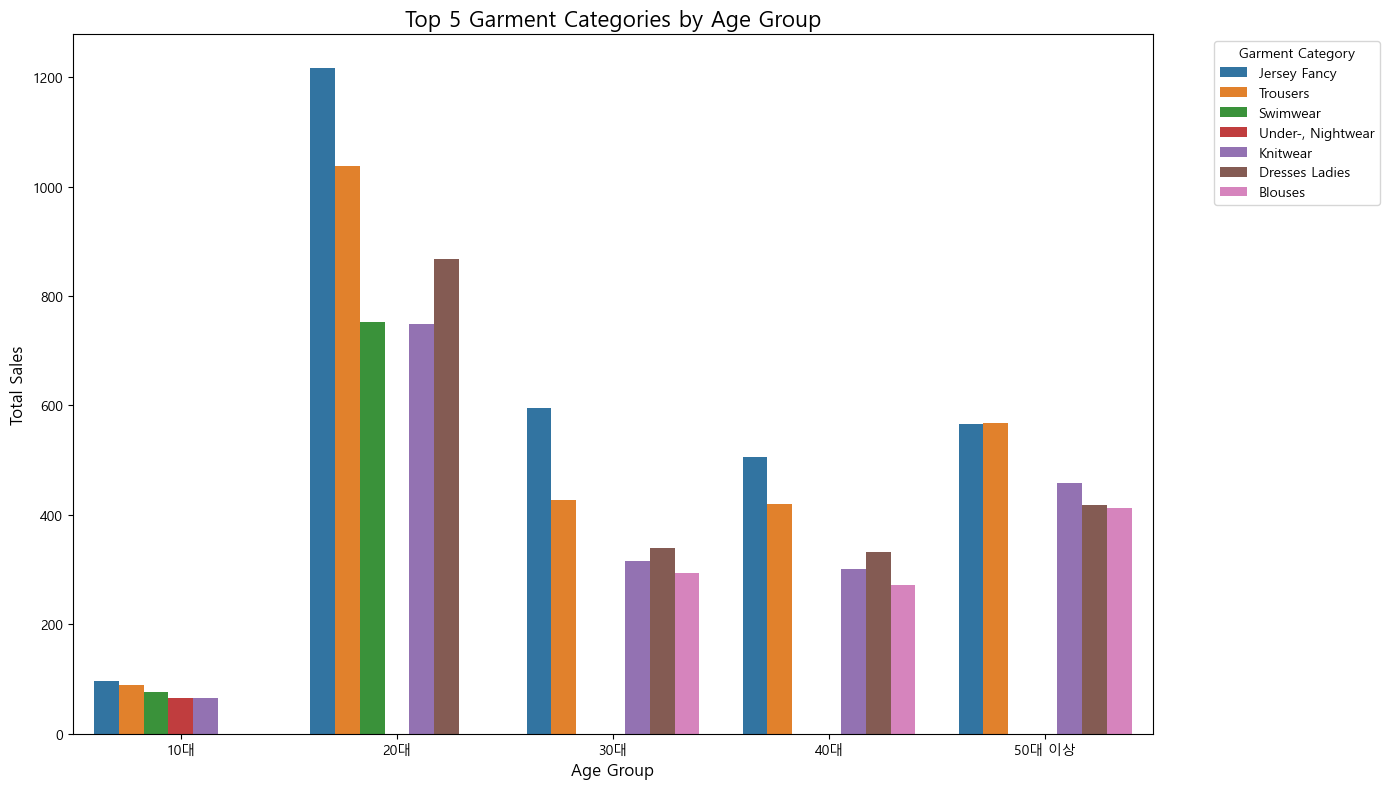

In [55]:
N = 5

topn = (products_prefer.sort_values(['age_group', 'price'], ascending=[True, False])
               .groupby('age_group')
               .head(N)
)

#시각화
plt.figure(figsize=(14, 8))
sns.barplot(
    data=topn,
    x='age_group',
    y='price',
    hue='garment_group_name'
)

plt.title(f'Top {N} Garment Categories by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(title='Garment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

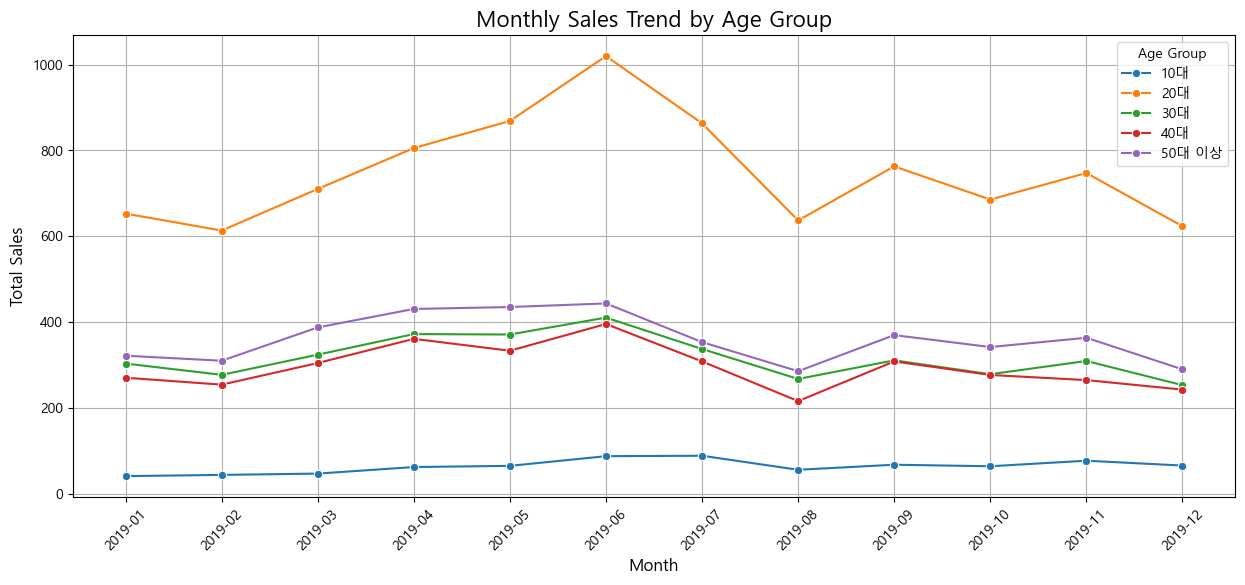

In [56]:
#연령대별 월간 매출 합계

merge['t_dat'] = pd.to_datetime(merge['t_dat'])
merge['year_month'] = merge['t_dat'].dt.to_period('M')


monthly_sales = merge.groupby(['year_month', 'age_group'])['price'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# 시각화
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='year_month', y='price', hue='age_group', marker='o')

plt.title('Monthly Sales Trend by Age Group', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Age Group')
plt.grid(True)
plt.show()



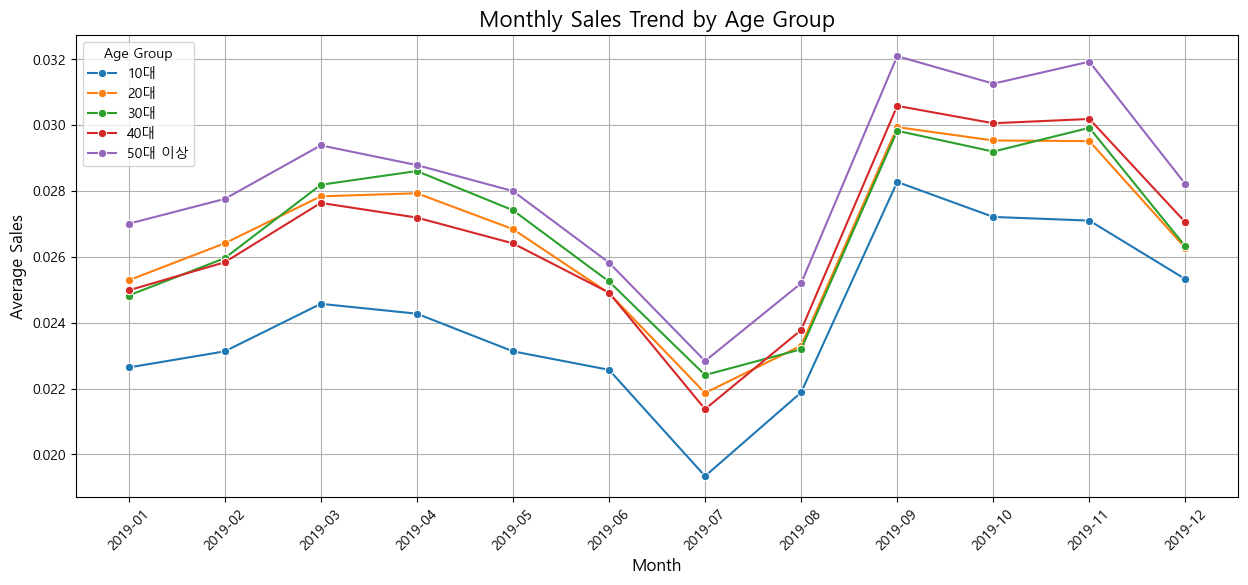

In [47]:
#연령대별 월간 매출 평균 추이


# 날짜 처리
merge['t_dat'] = pd.to_datetime(merge['t_dat'])
merge['year_month'] = merge['t_dat'].dt.to_period('M')


monthly_mean = merge.groupby(['year_month', 'age_group'])['price'].mean().reset_index()
monthly_mean['year_month'] = monthly_sales['year_month'].astype(str)

# 시각화
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_mean, x='year_month', y='price', hue='age_group', marker='o')

plt.title('Monthly Sales Trend by Age Group', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Age Group')
plt.grid(True)
plt.show()



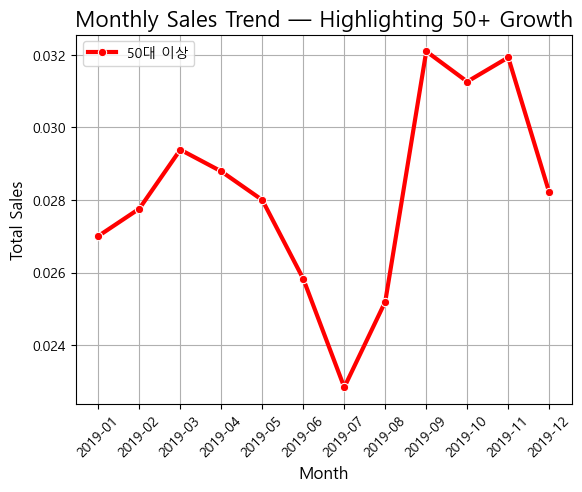

In [48]:
# 50대만 강조
sns.lineplot(
    data=monthly_mean[monthly_sales['age_group'] == '50대 이상'],
    x='year_month', y='price', color='red', linewidth=3, marker='o', label='50대 이상'
)

plt.title('Monthly Sales Trend — Highlighting 50+ Growth', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()